# Cluster + majority-vote dialect ID -- fully automatic variant

A seventh method, the automatic counterpart to
`06_cluster_propagation.ipynb`: **same** sentence-embedding K-Means
clustering (`k-means++` init, tokenize -> average token embeddings via
the frozen `CBOWAttention`), but **no human annotation step at all**.
Each cluster's label is decided by a **majority vote over its own
training members' existing (Qwen-generated) `train.jsonl` labels** --
unlike notebook 06, which deliberately never let clustering or labeling
see those labels (only a diagnostic peek). Here, the whole point is the
opposite: use the full training-label signal, just applied *per
cluster* instead of *per row*, to see how much a K-Means clustering
step adds (or costs) versus classifying every row directly.

**Pipeline**: cluster `train.jsonl` (script-gated, `code_switch`/`other`
excluded, same convention as everywhere else) -> label each cluster by
its members' majority `label` -> assign each `test.jsonl` row to its
nearest **train-fitted** centroid (no leakage) -> predict that cluster's
majority label -> compare to the real test label.

**Cluster-count sweep**: `k = 100, 200, 500, 1000` per group, same
`k-means++` initialization throughout (spreads initial centroids apart
by distance rather than picking them uniformly at random -- the "good
initialization" that keeps k this large from converging to degenerate,
near-empty clusters), `n_init=10` (best of 10 independent k-means++
seeds by inertia) at every k. Tests whether finer-grained clusters
(more, smaller, more homogeneous by construction) trade off against
noisier per-cluster majority votes as clusters shrink toward only a
handful of training members each.

Fully automatic end to end -- no webpage, no waiting, runs in one pass.
Run this notebook's kernel from the GPU venv (`ai-gpu`).


In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"
WORD2VEC_ATTENTION_DIR = ROOT / "Embeddings" / "word2vec_attention"

sys.path.insert(0, str(WORD2VEC_ATTENTION_DIR / "scripts"))
sys.path.insert(0, str(ROOT / "Tokenization"))
from model import CBOWAttention  # noqa: E402
from tokenizer_utils import load_tokenizer  # noqa: E402

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")  # embedding lookups only -- GPU not needed


## 1. Script-gating (same convention as every other method here)

In [2]:
import re

_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")
_ARABIC_RE = re.compile(r"[\u0600-\u06ff\u0750-\u077f\u08a0-\u08ff\ufb50-\ufdff\ufe70-\ufeff]")
_LATIN_RE = re.compile(r"[a-zA-Z\u00c0-\u024f]")

ARABIC_CLASSES = ["msa", "darija"]
LATIN_CLASSES = ["arabize", "french", "english"]
GROUP_CLASSES = {"arabic": ARABIC_CLASSES, "latin": LATIN_CLASSES}

MAX_CHARS = 500  # same truncation convention as label_dataset.py's MAX_PROMPT_CHARS


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def script_of(text: str) -> str:
    has_ar = bool(_ARABIC_RE.search(text))
    has_lat = bool(_LATIN_RE.search(text))
    if has_ar and has_lat:
        return "mixed"
    if has_ar:
        return "arabic"
    if has_lat:
        return "latin"
    return "other"


def load_group_rows(split: str, group: str) -> list[dict]:
    rows = []
    with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            r = json.loads(line)
            cleaned = clean_for_classification(r["text"])
            if script_of(cleaned) != group:
                continue
            rows.append({"id": r["id"], "text": r["text"], "label": r["label"]})
    return rows


## 2. Load the frozen embedder + sentence embeddings (computed once, reused across every k)

Identical to notebook 06: tokenize the whole text, average its token
embeddings -- no per-word pooling, no attention/context block. Embedding
every train/test row is the expensive step, so it's done once here and
reused for all four values of k below (only the clustering itself needs
to rerun per k).

In [3]:
meta = json.loads((WORD2VEC_ATTENTION_DIR / "data" / "meta.json").read_text(encoding="utf-8"))
tok = load_tokenizer(meta["tokenizer"]["key"], meta["tokenizer"]["vocab_size"])
vocab_size = meta["tokenizer"]["vocab_size_actual"]
PAD_ID = 0

checkpoints = sorted(
    (WORD2VEC_ATTENTION_DIR / "models").glob("checkpoint_step*.pt"),
    key=lambda p: int(p.stem.split("step")[-1]),
)
CHECKPOINT = checkpoints[-1]
ckpt = torch.load(CHECKPOINT, map_location=device)
ckpt_args = ckpt["args"]

embedder = CBOWAttention(
    vocab_size=vocab_size, embed_dim=ckpt_args["embed_dim"],
    num_heads=ckpt_args["num_heads"], ff_dim=ckpt_args["ff_dim"],
).to(device)
embedder.load_state_dict(ckpt["model_state_dict"])
embedder.eval()

EMBED_DIM = ckpt_args["embed_dim"]
embedding_matrix = embedder.input_embeddings.weight.detach().cpu().numpy()
print(f"Loaded checkpoint step={ckpt['step']:,} ({CHECKPOINT.name}), embed_dim={EMBED_DIM}")


def sentence_embedding(text: str) -> np.ndarray:
    ids = [i for i in tok.encode(text[:MAX_CHARS]) if i != PAD_ID and i < vocab_size]
    if not ids:
        return np.zeros(EMBED_DIM, dtype=np.float32)
    return embedding_matrix[ids].mean(axis=0)


group_data = {}
for group in ("arabic", "latin"):
    train_rows = load_group_rows("train", group)
    test_rows = load_group_rows("test", group)
    train_embeddings = np.stack([sentence_embedding(r["text"]) for r in train_rows])
    test_embeddings = np.stack([sentence_embedding(r["text"]) for r in test_rows])
    group_data[group] = dict(train_rows=train_rows, test_rows=test_rows,
                              train_embeddings=train_embeddings, test_embeddings=test_embeddings)
    print(f"{group}: train={len(train_rows):,}  test={len(test_rows):,}")


Loaded checkpoint step=675,000 (checkpoint_step675000.pt), embed_dim=128


arabic: train=6,660  test=1,665


latin: train=4,563  test=1,142


## 3. Sweep k = 100, 200, 500, 1000 -- cluster, majority-vote label, evaluate

For each k: fit K-Means on the group's train embeddings (`k-means++`,
`n_init=10`), label every cluster by a majority vote over its members'
existing labels, assign every test row to its nearest **train-fitted**
centroid (no leakage), predict that cluster's label, score against the
real test label.

In [4]:
K_VALUES = [100, 200, 500, 1000]

sweep_results = []  # one row per (group, k)
per_k_state = {}    # (group, k) -> kmeans/cluster_labels/predictions, for confusion matrices later

for group, gd in group_data.items():
    rows = gd["train_rows"]
    embeddings = gd["train_embeddings"]
    test_rows = gd["test_rows"]
    test_embeddings = gd["test_embeddings"]
    classes = GROUP_CLASSES[group]

    for k in K_VALUES:
        t0 = time.time()
        kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=SEED)
        cluster_ids = kmeans.fit_predict(embeddings)

        cluster_labels = {}
        cluster_purities = {}
        singleton_clusters = 0
        for c in range(k):
            member_idx = np.where(cluster_ids == c)[0]
            if len(member_idx) == 0:
                continue
            if len(member_idx) == 1:
                singleton_clusters += 1
            member_labels = [rows[i]["label"] for i in member_idx]
            counts = {}
            for l in member_labels:
                counts[l] = counts.get(l, 0) + 1
            majority_label, majority_count = max(counts.items(), key=lambda kv: kv[1])
            cluster_labels[c] = majority_label
            cluster_purities[c] = majority_count / len(member_labels)

        weighted_purity = np.average(
            list(cluster_purities.values()),
            weights=[(cluster_ids == c).sum() for c in cluster_purities],
        )

        pred_cluster_ids = kmeans.predict(test_embeddings)
        y_true = [r["label"] for r in test_rows]
        y_pred = [cluster_labels[c] for c in pred_cluster_ids]
        acc = accuracy_score(y_true, y_pred)

        sweep_results.append({
            "group": group, "k": k, "non_empty_clusters": len(cluster_labels),
            "singleton_clusters": singleton_clusters, "mean_cluster_size": len(rows) / len(cluster_labels),
            "train_purity": weighted_purity, "test_accuracy": acc,
        })
        per_k_state[(group, k)] = dict(kmeans=kmeans, cluster_labels=cluster_labels,
                                        y_true=y_true, y_pred=y_pred)
        print(f"{group:<7} k={k:<5} non_empty={len(cluster_labels):<5} singletons={singleton_clusters:<5} "
              f"purity={weighted_purity:.3f}  test_acc={acc:.4f}  ({time.time() - t0:.1f}s)")

import pandas as pd
sweep_df = pd.DataFrame(sweep_results)
sweep_df


arabic  k=100   non_empty=100   singletons=8     purity=0.795  test_acc=0.7802  (19.8s)


arabic  k=200   non_empty=200   singletons=51    purity=0.805  test_acc=0.7886  (24.0s)


arabic  k=500   non_empty=500   singletons=224   purity=0.822  test_acc=0.7958  (39.3s)


arabic  k=1000  non_empty=1000  singletons=649   purity=0.833  test_acc=0.7952  (85.6s)


latin   k=100   non_empty=100   singletons=12    purity=0.831  test_acc=0.8284  (5.9s)


latin   k=200   non_empty=200   singletons=39    purity=0.843  test_acc=0.8459  (12.0s)


latin   k=500   non_empty=500   singletons=258   purity=0.859  test_acc=0.8284  (26.7s)


latin   k=1000  non_empty=1000  singletons=728   purity=0.891  test_acc=0.8345  (65.6s)


,group,k,non_empty_clusters,singleton_clusters,mean_cluster_size,train_purity,test_accuracy
0,arabic,100,100,8,66.600,0.795495,0.780180
1,arabic,200,200,51,33.300,0.805255,0.788589
2,arabic,500,500,224,13.320,0.821622,0.795796
3,arabic,1000,1000,649,6.660,0.833333,0.795195
4,latin,100,100,12,45.630,0.831471,0.828371
5,latin,200,200,39,22.815,0.843086,0.845884
6,latin,500,500,258,9.126,0.859084,0.828371
7,latin,1000,1000,728,4.563,0.891300,0.834501


## 4. Per-class accuracy at each k

In [5]:
for group in group_data:
    classes = GROUP_CLASSES[group]
    print(f"\n=== {group} ===")
    header = f"{'k':<8}" + "".join(f"{c:>12}" for c in classes)
    print(header)
    for k in K_VALUES:
        state = per_k_state[(group, k)]
        y_true, y_pred = state["y_true"], state["y_pred"]
        row = f"{k:<8}"
        for cname in classes:
            idx = [i for i, t in enumerate(y_true) if t == cname]
            n_correct = sum(y_pred[i] == cname for i in idx)
            acc = n_correct / len(idx) if idx else float("nan")
            row += f"{acc:>12.3f}"
        print(row)



=== arabic ===
k                msa      darija
100            0.491       0.920
200            0.500       0.928
500            0.577       0.901
1000           0.542       0.917

=== latin ===
k            arabize      french     english
100            0.892       0.843       0.396
200            0.908       0.841       0.500
500            0.881       0.846       0.453
1000           0.899       0.829       0.481


## 5. Confusion matrix at the best k per group

In [6]:
def print_confusion(classes, y_true, y_pred, title):
    n = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    mat = [[0] * n for _ in range(n)]
    for t, p in zip(y_true, y_pred):
        mat[idx[t]][idx[p]] += 1
    print(f"\n{title} confusion matrix (rows=true, cols=predicted):")
    print("true\\pred" + "".join(f"{c:>12}" for c in classes))
    for i, c in enumerate(classes):
        print(f"{c:<10}" + "".join(f"{mat[i][j]:>12}" for j in range(n)))


for group in group_data:
    sub = sweep_df[sweep_df["group"] == group]
    best_k = int(sub.loc[sub["test_accuracy"].idxmax(), "k"])
    state = per_k_state[(group, best_k)]
    print_confusion(GROUP_CLASSES[group], state["y_true"], state["y_pred"], f"{group} (best k={best_k})")



arabic (best k=500) confusion matrix (rows=true, cols=predicted):
true\pred         msa      darija
msa                313         229
darija             111        1012

latin (best k=200) confusion matrix (rows=true, cols=predicted):
true\pred     arabize      french     english
arabize            564          52           5
french              60         349           6
english             37          16          53


## 6. Accuracy and purity vs. k

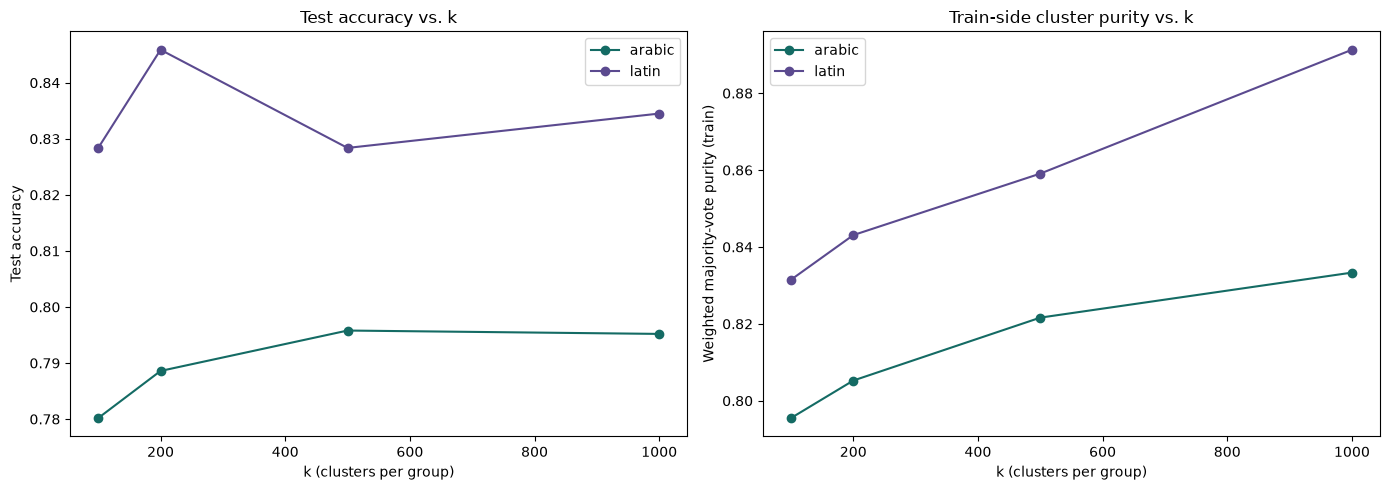

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"arabic": "#146b64", "latin": "#5b4a8f"}
for group in group_data:
    sub = sweep_df[sweep_df["group"] == group].sort_values("k")
    axes[0].plot(sub["k"], sub["test_accuracy"], marker="o", label=group, color=colors[group])
    axes[1].plot(sub["k"], sub["train_purity"], marker="o", label=group, color=colors[group])

axes[0].set_xlabel("k (clusters per group)")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Test accuracy vs. k")
axes[0].legend()
axes[1].set_xlabel("k (clusters per group)")
axes[1].set_ylabel("Weighted majority-vote purity (train)")
axes[1].set_title("Train-side cluster purity vs. k")
axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Compared against every other method tried on this task

In [8]:
best_by_group = {
    group: sweep_df[sweep_df["group"] == group].sort_values("test_accuracy", ascending=False).iloc[0]
    for group in group_data
}

comparison = {
    "word-cluster baseline (per-word K-Means + tally)": {"arabic": 0.562, "latin": 0.562},  # cluster-scored, combined
    "classifier head (transformer)": {"arabic": 0.819, "latin": 0.863},
    "n-gram + SVM-RBF (best)": {"arabic": 0.833, "latin": 0.881},
    "Cavnar & Trenkle (n-gram profiles)": {"arabic": 0.754, "latin": 0.844},
    "cluster + 200 human-labeled prototypes": {"arabic": 0.701, "latin": 0.810},
    "cluster + majority vote, k=100": {"arabic": sweep_df[(sweep_df.group == "arabic") & (sweep_df.k == 100)]["test_accuracy"].iloc[0],
                                        "latin": sweep_df[(sweep_df.group == "latin") & (sweep_df.k == 100)]["test_accuracy"].iloc[0]},
    "cluster + majority vote, best k (this notebook)": {"arabic": best_by_group["arabic"]["test_accuracy"],
                                                          "latin": best_by_group["latin"]["test_accuracy"]},
}

print(f"{'method':<50}{'arabic':>10}{'latin':>10}")
for name, scores in sorted(comparison.items(), key=lambda kv: kv[1]["arabic"]):
    print(f"{name:<50}{scores['arabic']:>10.3f}{scores['latin']:>10.3f}")

print(f"\nBest k overall: arabic k={int(best_by_group['arabic']['k'])}, latin k={int(best_by_group['latin']['k'])}")


method                                                arabic     latin
word-cluster baseline (per-word K-Means + tally)       0.562     0.562
cluster + 200 human-labeled prototypes                 0.701     0.810
Cavnar & Trenkle (n-gram profiles)                     0.754     0.844
cluster + majority vote, k=100                         0.780     0.828
cluster + majority vote, best k (this notebook)        0.796     0.846
classifier head (transformer)                          0.819     0.863
n-gram + SVM-RBF (best)                                0.833     0.881

Best k overall: arabic k=500, latin k=200


## Misclassified examples

A sample of what this method actually gets wrong, per group. At the
best k per group (same one the confusion matrix above used) --
`gd["test_rows"]` (the original row dicts, with `text`) line up in
order with `per_k_state[(group, best_k)]`'s `y_true`/`y_pred`.

In [9]:
import random

random.seed(0)

for group in group_data:
    sub = sweep_df[sweep_df["group"] == group]
    best_k = int(sub.loc[sub["test_accuracy"].idxmax(), "k"])
    state = per_k_state[(group, best_k)]
    test_rows = group_data[group]["test_rows"]

    wrong = [
        (row["text"], t, p)
        for row, t, p in zip(test_rows, state["y_true"], state["y_pred"]) if t != p
    ]
    print(f"\n=== {group} (best k={best_k}): {len(wrong)}/{len(test_rows)} misclassified "
          f"({len(wrong) / len(test_rows):.1%}) ===")
    for text, true_label, pred_label in random.sample(wrong, min(10, len(wrong))):
        snippet = text[:140] + ("..." if len(text) > 140 else "")
        print(f"\n  true={true_label}  pred={pred_label}")
        print(f"  {snippet!r}")



=== arabic (best k=500): 340/1665 misclassified (20.4%) ===

  true=msa  pred=darija
  '[MENTION] الصحراء مغربية و ستبقى مغربية إلى الأبد و الاستقلال للمزاب و القبايل من الاحتلال العسكري الجزاءري'

  true=msa  pred=darija
  'تحيا أمازيغية الأحرار على طريقة ابن باديس و ازواوي و الشهداء من تاريخ الامازيغ الاحرار الذين حرروا الوطن و حملوا راية الاسلام\n\nو ليس أمازيغي...'

  true=msa  pred=darija
  'اكثر من 80 عائلة بدون دخل كانت تسترزق من المحجرة بدون الاستثمارات الاخرى في الزراعة والبناء والسياحة'

  true=msa  pred=darija
  'نظافة البيئة واجب على المواطنين'

  true=msa  pred=darija
  'السلام عليك اختي بما انك تريدين تعلم اللغة الامازيغية اوجهك الى عنوان آخر وموجود في هذا المنتدى ويحمل اسم اتعلم اللغة وستجدين كل ما تحتاجين ...'

  true=msa  pred=darija
  'وتعاونوا على البر والتقوى ولا تعاونو على الاثم والعدوان'

  true=msa  pred=darija
  'هذا يقول لماذا ينقمون على الشيخ ربيع خاصة بعد ممات الشيخ ابن باز و الشيخ العثيمين و الشيخ الألباني ؟\nالجواب :\nلا هم ينقمون على الشيخ ربيع حت...'

  